# Variance parameters from last season

Goal: use 2025 weekly actuals to measure, per position and **per tier**, (1) how volatile players are week to week (`CV = std / mean`) and (2) how often they're available (games out of 17). These feed the season simulator, which attaches them to each Sleeper projection.

We measure **within-player** CV -- each player's spread around *his own* average -- because that's what the simulator samples.

Run this from the repo root so the `data/` save path lines up.

In [9]:
import nflreadpy as nfl
import polars as pl
from pathlib import Path
pl.Config.set_tbl_rows(-1)

SEASON = 2025  # last completed season -- our source of truth for variance

# Week-level player stats (Polars). fantasy_points / fantasy_points_ppr are
# already computed, so we don't score anything ourselves.
weekly = nfl.load_player_stats(seasons=[SEASON]).filter(pl.col("season_type") == "REG")

print("shape:", weekly.shape)
print(weekly.columns)

shape: (18539, 145)
['player_id', 'player_name', 'player_display_name', 'position', 'position_group', 'headshot_url', 'season', 'week', 'season_type', 'game_id', 'team', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions', 'pacr', 'passing_10', 'passing_16', 'passing_20', 'passing_40', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'rushing_10', 'rushing_12', 'rushing_20', 'rushing_40', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_fumbles', 'receiving_fumbles_lost', 'receiving_air_yards', 'receiving_yards_after_catch', 'receiving_first_downs', 'receiving_epa', 'receiving_2pt_conversions', 'receiving_10', 'rec

If the position filter below returns 0 rows, the column may be `position_group` rather than `position` -- check the list printed above and swap it.

In [10]:
POSITIONS = ["QB", "RB", "WR", "TE"]   # K and DEF need separate handling; later
PTS = "fantasy_points_ppr"              # switch to "fantasy_points" for standard scoring

# One row per player per game played. A player inactive/injured that week has
# NO row -- that's how we measure availability later.
wk = (
    weekly
    .filter(pl.col("position").is_in(POSITIONS))
    .select(["player_id", "position", "week", PTS])
    .rename({PTS: "pts"})
    .drop_nulls("pts")
)
print("weekly player-game rows:", wk.height)
wk.head()

weekly player-game rows: 6020


player_id,position,week,pts
str,str,i32,f64
"""00-0023459""","""QB""",1,25.66
"""00-0026158""","""QB""",1,12.2
"""00-0026498""","""QB""",1,13.6
"""00-0029263""","""QB""",1,11.12
"""00-0030035""","""WR""",1,2.0


## Per-player week-to-week spread

For each player: games, mean, std, total, and CV. Require a minimum number of
games so the std is trustworthy.

In [11]:
MIN_GAMES = 6

per_player = (
    wk.group_by(["player_id", "position"])
    .agg(
        games=pl.len(),
        mean_pts=pl.col("pts").mean(),
        std_pts=pl.col("pts").std(),
        total_pts=pl.col("pts").sum(),
    )
    .filter((pl.col("games") >= MIN_GAMES) & (pl.col("mean_pts") > 0))
    .with_columns(cv=pl.col("std_pts") / pl.col("mean_pts"))
)
print(f"players with >= {MIN_GAMES} games:", per_player.height)
per_player.sort("total_pts", descending=True).head(10)

players with >= 6 games: 425


player_id,position,games,mean_pts,std_pts,total_pts,cv
str,str,u32,f64,f64,f64,f64
"""00-0033280""","""RB""",17,24.505882,8.224466,416.6,0.335612
"""00-0039075""","""WR""",16,23.4375,10.208812,375.0,0.435576
"""00-0038542""","""RB""",17,21.811765,10.258404,370.8,0.470315
"""00-0039139""","""RB""",17,21.582353,13.527206,366.9,0.626772
"""00-0034857""","""QB""",16,22.78875,10.404942,364.62,0.456582
"""00-0036223""","""RB""",17,21.311765,12.441507,362.3,0.583786
"""00-0038543""","""WR""",17,21.170588,7.481207,359.9,0.353377
"""00-0039851""","""QB""",17,20.703529,5.388322,351.96,0.260261
"""00-0026498""","""QB""",17,20.610588,6.979442,350.38,0.338634


## Validation: startable-tier CV vs the literature

A quick check that the computation is sound before we go further: measure CV on
just the startable tier and compare to published values (QB ~0.37, RB ~0.55,
WR ~0.60, TE ~0.65). Ballpark agreement = trust it.

In [12]:
STARTER_COUNTS = {"QB": 12, "RB": 24, "WR": 36, "TE": 12}
counts = pl.DataFrame({"position": list(STARTER_COUNTS), "starter_n": list(STARTER_COUNTS.values())})

ranked = per_player.with_columns(
    rank=pl.col("mean_pts").rank(method="ordinal", descending=True).over("position")
)
startable = ranked.join(counts, on="position").filter(pl.col("rank") <= pl.col("starter_n"))

pos_cv = (
    startable.group_by("position")
    .agg(n=pl.len(), cv_median=pl.col("cv").median(), avg_ppg=pl.col("mean_pts").mean())
    .sort("position")
)
pos_cv

position,n,cv_median,avg_ppg
str,u32,f64,f64
"""QB""",12,0.435653,19.453055
"""RB""",24,0.526595,16.123348
"""TE""",12,0.563114,12.913774
"""WR""",36,0.569896,14.279749


## Availability (games out of 17)

Missed games are the dominant season-long risk. Average games played over 17
gives a per-week availability. We defined this tier by per-game scoring, so it's
only mildly biased toward the healthy -- a fine first estimate.

In [13]:
GAMES_IN_SEASON = 17

avail = (
    startable.group_by("position")
    .agg(avg_games=pl.col("games").mean(), median_games=pl.col("games").median())
    .with_columns(availability=pl.col("avg_games") / GAMES_IN_SEASON)
    .sort("position")
)
avail

position,avg_games,median_games,availability
str,f64,f64,f64
"""QB""",15.833333,17.0,0.931373
"""RB""",15.541667,17.0,0.914216
"""TE""",14.416667,16.5,0.848039
"""WR""",14.944444,16.0,0.879085


## Tiered CV -- the real lookup

Volatility scales inversely with scoring: studs are steady (low CV), the fringe
is boom/bust (CV near 1.0, where std equals mean). A single per-position CV would
paint a WR50 as steady as a WR5 and erase the most useful draft signal, so we
tier.

We now define tiers by **season production** (`total_pts`) rather than per-game
rank, because that's the axis we'll classify new players on -- a Sleeper season
projection *is* expected season points. `proj_floor` (the lowest season total in
each tier) becomes the cutoff the simulator compares a projection against.

In [14]:
tiered = (
    per_player
    .with_columns(rank=pl.col("total_pts").rank(method="ordinal", descending=True).over("position"))
    .with_columns(
        tier=pl.when(pl.col("rank") <= 12).then(pl.lit("elite"))
              .when(pl.col("rank") <= 36).then(pl.lit("starter"))
              .otherwise(pl.lit("bench"))
    )
)

cv_by_tier = (
    tiered.group_by(["position", "tier"])
    .agg(
        n=pl.len(),
        cv=pl.col("cv").median(),
        proj_floor=pl.col("total_pts").min(),   # lowest season total in tier = its cutoff
        avg_ppg=pl.col("mean_pts").mean(),
    )
    .sort(["position", "proj_floor"], descending=[False, True])
)
cv_by_tier

position,tier,n,cv,proj_floor,avg_ppg
str,str,u32,f64,f64,f64
"""QB""","""elite""",12,0.43098,271.92,19.143589
"""QB""","""starter""",24,0.557177,99.14,14.154917
"""QB""","""bench""",7,1.006645,4.22,7.022861
"""RB""","""elite""",12,0.467638,242.8,18.353676
"""RB""","""starter""",24,0.641792,128.9,11.669906
"""RB""","""bench""",67,1.007675,0.4,4.146071
"""TE""","""elite""",12,0.572492,165.1,12.087085
"""TE""","""starter""",24,0.686956,78.7,8.631998
"""TE""","""bench""",61,0.986873,0.4,3.009207


Expect CV to climb across tiers, with a sharp jump into the bench (~1.0).
Two cleanups before saving: the **bench** tier catches everyone below the starter
cutoff, so its floor becomes 0; and the **QB bench** row is only a handful of
noisy players (nobody simulates a QB4), so we drop it and let 'starter' cover
every non-elite QB.

In [15]:
# Build the simulator's lookup: position, tier, cv, proj_floor, availability.
params = cv_by_tier.select(["position", "tier", "cv", "proj_floor"])

# Bench floor -> 0 (it catches everyone below the starter cutoff).
params = params.with_columns(
    pl.when(pl.col("tier") == "bench").then(0.0).otherwise(pl.col("proj_floor")).alias("proj_floor")
)

# Drop the thin/noisy QB bench; let QB 'starter' cover everyone non-elite.
params = params.filter(~((pl.col("position") == "QB") & (pl.col("tier") == "bench")))
params = params.with_columns(
    pl.when((pl.col("position") == "QB") & (pl.col("tier") == "starter")).then(0.0)
      .otherwise(pl.col("proj_floor")).alias("proj_floor")
)

# Attach per-position availability.
params = (
    params.join(avail.select(["position", "availability"]), on="position")
    .sort(["position", "proj_floor"], descending=[False, True])
)

DATA = Path("data")   # assumes Jupyter launched from the repo root
DATA.mkdir(exist_ok=True)
params.write_parquet(DATA / "variance_params.parquet")
print("wrote", DATA / "variance_params.parquet")
params

wrote data\variance_params.parquet


position,tier,cv,proj_floor,availability
str,str,f64,f64,f64
"""QB""","""elite""",0.43098,271.92,0.931373
"""QB""","""starter""",0.557177,0.0,0.931373
"""RB""","""elite""",0.467638,242.8,0.914216
"""RB""","""starter""",0.641792,128.9,0.914216
"""RB""","""bench""",1.007675,0.0,0.914216
"""TE""","""elite""",0.572492,165.1,0.848039
"""TE""","""starter""",0.686956,78.7,0.848039
"""TE""","""bench""",0.986873,0.0,0.848039
"""WR""","""elite""",0.523233,219.9,0.879085


**How the simulator will read this:** for a player, filter to his position,
then pick the tier whose `proj_floor` is the highest value still <= his Sleeper
season projection. That gives the `cv` to sample with and the `availability` to
gate weeks by. Cutoffs come from 2025 actual season totals, which is fair because
production levels are stable year to year.

## Optional: eyeball the distribution shape

RB weekly points should show the right-skewed, floored-at-zero shape our gamma
sampler assumes.

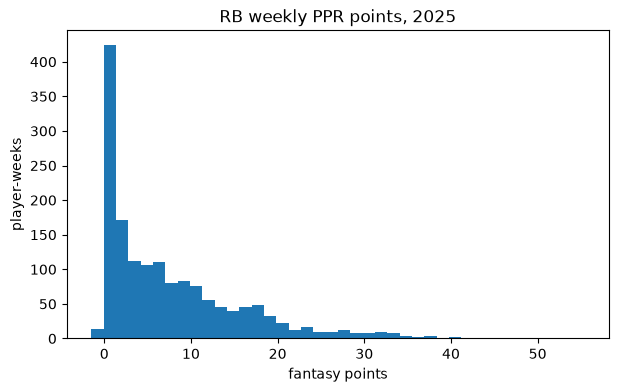

In [16]:
import matplotlib.pyplot as plt

rb_pts = wk.filter(pl.col("position") == "RB")["pts"].to_numpy()
plt.figure(figsize=(7, 4))
plt.hist(rb_pts, bins=40)
plt.title("RB weekly PPR points, 2025")
plt.xlabel("fantasy points"); plt.ylabel("player-weeks")
plt.show()